# Implement LeNet-5 on MNIST Dataset

In [7]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from dataclasses import dataclass
import numpy as np

### Read the dataset

In [3]:
def getData():
    return mnist.load_data(path="mnist.npz")

### Pre-process the dataset

In [9]:
def preprocessDataset(train_set, test_set, resize_to=None, num_classes=10, seed=3):
    (X_train, y_train) = train_set
    (X_test, y_test) = test_set

    # Split the training dataset into training and validation dataset
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train,
        y_train,
        shuffle=True,
        test_size=0.1,
        stratify=y_train,
        random_state=seed,
    )

    # Add axis to gray scale
    if len(X_train.shape) != 4:
        X_train = tf.expand_dims(X_train, axis=3)
        X_valid = tf.expand_dims(X_valid, axis=3)
        X_test = tf.expand_dims(X_test, axis=3)

    # Resize images if requested
    if resize_to:
        if isinstance(resize_to, int):
            resize_to = (resize_to, resize_to)

        X_train = tf.image.resize(X_train, resize_to)
        X_valid = tf.image.resize(X_valid, resize_to)
        X_test = tf.image.resize(X_test, resize_to)

    n_train = X_train.shape[0]
    n_valid = X_valid.shape[0]
    n_test = X_test.shape[0]

    image_shape = X_train[0].shape

    print("\n")
    print(f"Num of training examples: {n_train}")
    print(f"Num of validation examples: {n_valid}")
    print(f"Num of test examples: {n_test}")
    print(f"Image data shape: {image_shape}")

    # Confirm the number of classes
    assert (
        len(np.unique(y_train)) == num_classes
    ), "Number of classes in the dataset doesn't match specified number of classes"

    NUM_CLASSES = num_classes

    # One-hot encode the labels, if necessary
    if len(y_train.shape) != 2:
        y_train = tf.one_hot(y_train, NUM_CLASSES)
        y_valid = tf.one_hot(y_valid, NUM_CLASSES)
        y_test = tf.one_hot(y_test, NUM_CLASSES)

    print("\nData Split:\n")
    print(f"Shape X_train: {X_train.shape} y_train: {y_train.shape}")
    print(f"Shape X_valid: {X_valid.shape} y_valid: {y_valid.shape}")
    print(f"Shape X_test: {X_test.shape} y_test: {y_test.shape}")

    # Normalise pixel values to the range [0. - 1.]
    X_train = X_train / 255.0
    X_valid = X_valid / 255.0
    X_test = X_test / 255.0

    print("\nGround truth labels have been one-hot encoded: \n")
    print(np.transpose(y_train[:9]))

    return (X_train, y_train), (X_valid, y_valid), (X_test, y_test)

### Data Visualisation 

In [18]:
def visualiseSamples(X, y):
    plt.figure(figsize=(18, 8))

    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid("off")
        plt.imshow(X[i], cmap="gray")
        plt.xlabel(y[i])
        plt.axis("off")

    plt.suptitle("Dataset samples", fontsize=18)
    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.show(block=False)
    plt.close()

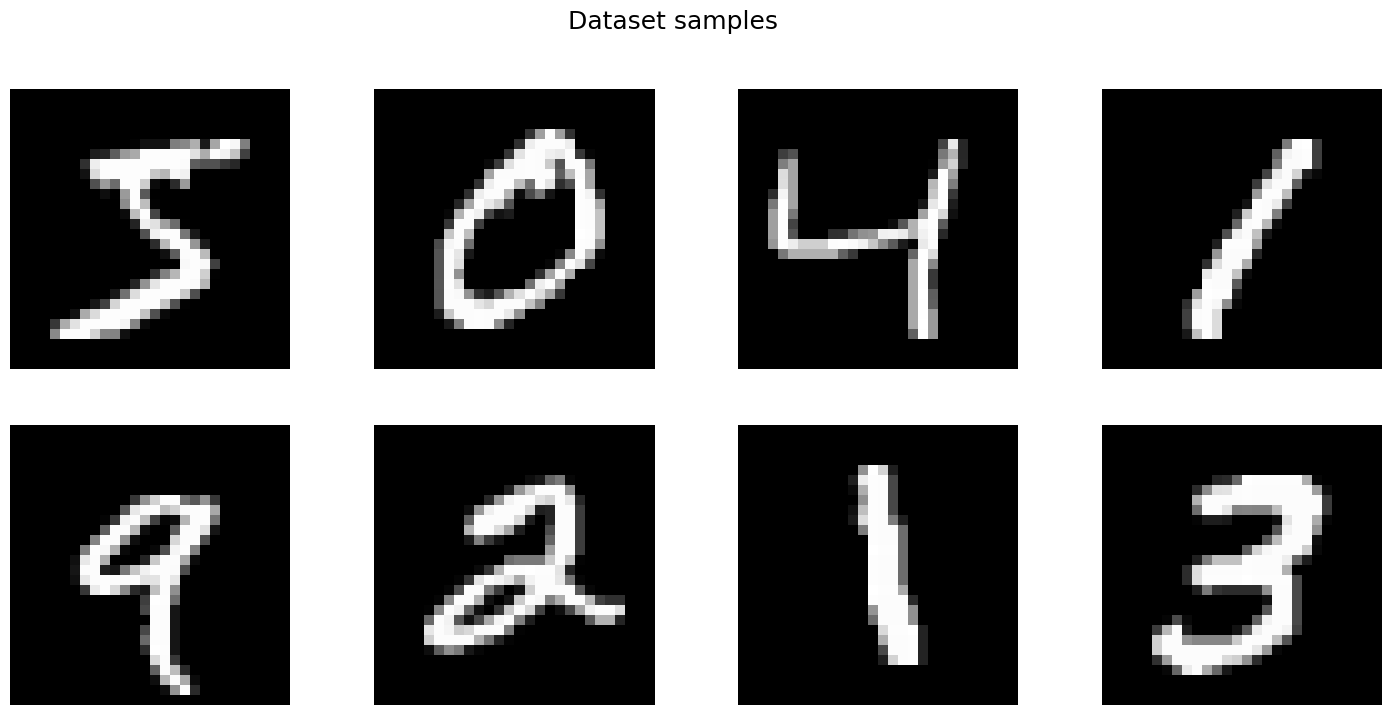

In [21]:
(X_train_in, y_train_in), (X_test_in, y_test_in) = getData()
visualiseSamples(X_train_in, y_train_in)

### Preprocess the Dataset

In [20]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 32
    IMG_WIDTH: int = 32
    CHANNELS: int = 1
    NUM_CLASSES: int = 10


@dataclass(frozen=True)
class TrainingConfig:
    LEARNING_RATE: float = 0.01
    BATCH_SIZE: int = 32
    EPOCHS: int = 21

In [22]:
dataConfig = DatasetConfig()

# Pre-process the dataset
((X_train, y_train), (X_valid, y_valid), (X_test, y_test)) = preprocessDataset(
    (X_train_in, y_train_in),
    (X_test_in, y_test_in),
    resize_to=(dataConfig.IMG_HEIGHT, dataConfig.IMG_WIDTH),
    num_classes=dataConfig.NUM_CLASSES,
)



Num of training examples: 54000
Num of validation examples: 6000
Num of test examples: 10000
Image data shape: (32, 32, 1)

Data Split:

Shape X_train: (54000, 32, 32, 1) y_train: (54000, 10)
Shape X_valid: (6000, 32, 32, 1) y_valid: (6000, 10)
Shape X_test: (10000, 32, 32, 1) y_test: (10000, 10)

Ground truth labels have been one-hot encoded: 

[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1.]]
